In [2]:
## Lecture 11

import torch

from torch import nn # all pytorch building blocks for neural networks
import matplotlib.pyplot as plt # for visualization

# print(f"Pytorch Version :{torch.__version__}")
# print(f"Cuda Available :{torch.cuda.is_available()}")
# print(f"Cuda Version :{torch.version.cuda}")
# print(f"GPU Device :{torch.cuda.get_device_name(0)}")

# Generating data
# Define ground truth for linear regression
# y = weight * x + bias
weight = 0.7 # Slope parameters
bias = 0.3 # True intercept parameter

# Generate synthetic data with known linear relationship
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)

y = weight * X + bias

# Display
print(f"X(first 10):{X[:10].flatten()}")
print(f"y (first 10):{y[:10].flatten()}")
print(X.shape, y.shape)

train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]

X_test, y_test = X[train_split:], y[train_split:]

# verify your results
print(len(X_train), len(y_train))
print(len(X_test), len(y_test))

assert len(X_train) + len(X_test) == len(X), "Data Partitioning error detected"

# import necessary utilities
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

BATCH_SIZE = 8
NUM_WORKERS = 0 # NUMBER of subprocesses for data loading

train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(train_dataloader, test_dataloader)



X(first 10):tensor([0.0000, 0.0200, 0.0400, 0.0600, 0.0800, 0.1000, 0.1200, 0.1400, 0.1600,
        0.1800])
y (first 10):tensor([0.3000, 0.3140, 0.3280, 0.3420, 0.3560, 0.3700, 0.3840, 0.3980, 0.4120,
        0.4260])
torch.Size([50, 1]) torch.Size([50, 1])
40 40
10 10
<torch.utils.data.dataloader.DataLoader object at 0x717db0994ec0> <torch.utils.data.dataloader.DataLoader object at 0x717db038e810>


In [3]:
# Lecture 12

def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    plt.figure(figsize=(10, 7))

    plt.scatter(train_data, train_labels, c="green", s=25, alpha=0.5, label="Training Data", marker='o')

    plt.scatter(test_data, test_labels, c="blue", s=15, alpha=0.7, label="Testing Data", marker='s')

    if predictions is not None:
        plt.scatter(test_data, predictions, c="red", s=25, alpha=0.8, marker='^', label="Predictions")

    plt.xlabel("Input features (X)", fontsize=12)
    plt.ylabel("Target values (y)", fontsize=12)
    plt.title("Linear Regression")
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()



In [4]:
# Lecture 13
import torch
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    """
    Linear Regression Model
    y = weight * x + bias
    - Input : One feature per sample/data point
    - Output: One value per sample/data point
    - Parameters : weight and bias
    """
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [ ]:
# Lecture 14

# custom loss functions
class MeanAbsoluteError(nn.Module):
    """
    MAE = mean(abs(y_pred - y_true))
    """
    def __init__(self):
        super().__init__()

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Computes Mean Absolute Error between predictions and targets

        Parameters:
        predictions: torch.Tensor, shape [batch_size, output_dim]
        targets: torch.Tensor, ground truth values with shape [batch_size, output_dim]

        Returns:
        torch.Tensor: scalar mean absolute error value
        """
        absolute_errors = torch.abs(predictions - targets)
        return torch.mean(absolute_errors)

In [ ]:
class HuberLoss(nn.Module):
    """
    custom Huber loss implementations
    -Quadratic loss for small errors (smooth gradients)
    -Linear for large errors (robust to outliers)
    L_delta(a) = 0.5*a*a if abs(a) <= delta
               = delta*(abs(a)-0.5*delta) if abs(a) > delta
    delta*a*b(a) -0.5*delta*delta
    """
    def __init__(self, delta: float = 1.0):
        super().__init__()
        self.delta = delta

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        predictions: torch.Tensor -> Model Predictions
        targets: torch.Tensor -> Ground truth

        Returns
        torch.Tensor -> Huber Loss -> scalar loss value
        """
        # Compute residuals
        residuals = predictions - targets
        abs_residuals = torch.abs(residuals)

        # Apply Huber loss formulations
        quadratic_mask = abs_residuals <= self.delta
        linear_mask = abs_residuals > self.delta

        quadratic_loss = 0.5 * residuals**2
        linear_loss = self.delta * abs_residuals - 0.5 * self.delta**2

        loss = quadratic_mask * quadratic_loss + linear_mask * linear_loss
        return torch.mean(loss)

# Note: MeanAbsoluteError class is not defined in the provided PDF,
# so the following lines would need that class defined elsewhere.

custom_mae_loss = MeanAbsoluteError()
huber_loss = HuberLoss(delta=1.0)

print("custom loss functions initialized")
print(f"custom MAE loss:{custom_mae_loss}")
print(f"Huber loss delta=1:{huber_loss}")

sample_predictions = torch.tensor([1., 2., 3.])
sample_targets = torch.tensor([1.1, 1.8, 3.2])

print(nn.L1Loss()(sample_predictions, sample_targets))
print(custom_mae_loss(sample_predictions, sample_targets))
print(huber_loss(sample_predictions, sample_targets))

Training samples: 100
Test samples: 50
Ground truth: weight = 7.0, bias = 3.0
Number of training batches: 7
Number of test batches: 4

INITIAL (RANDOM) PARAMETERS:
weight: 0.336690
bias: 0.128809


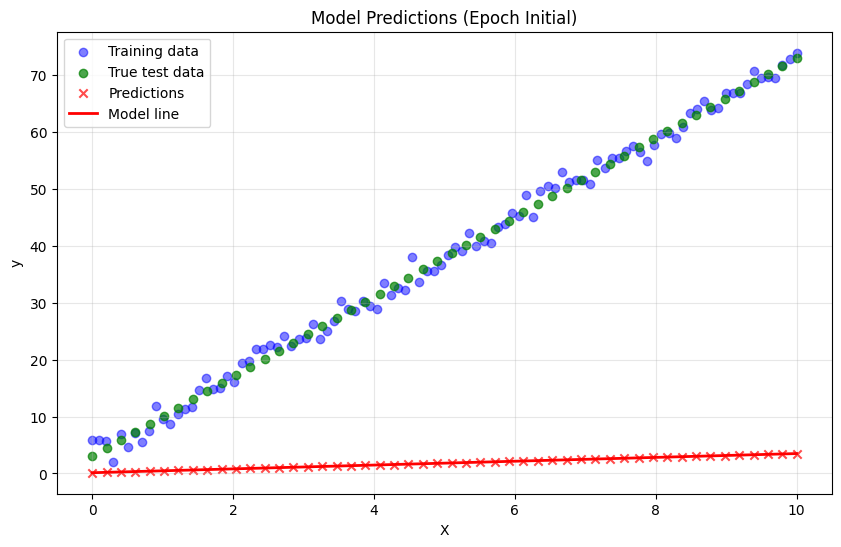


TRAINING CONFIGURATION:
Loss function: L1Loss
Optimizer: SGD
Learning rate: 0.01

TRAINING STARTING...
Epoch   0 | Train Loss: 37.032077 | Test Loss: 41.030810
Epoch  20 | Train Loss: 1.507368 | Test Loss: 0.633039
Epoch  40 | Train Loss: 1.285427 | Test Loss: 0.530910
Epoch  60 | Train Loss: 1.310357 | Test Loss: 0.435756
Epoch  80 | Train Loss: 1.268718 | Test Loss: 0.450949
Epoch 100 | Train Loss: 1.218889 | Test Loss: 0.361326
Epoch 120 | Train Loss: 1.282637 | Test Loss: 0.386179
Epoch 140 | Train Loss: 1.318786 | Test Loss: 0.269208
Epoch 160 | Train Loss: 1.139173 | Test Loss: 0.245622
Epoch 180 | Train Loss: 1.277294 | Test Loss: 0.258778
Epoch 200 | Train Loss: 1.230321 | Test Loss: 0.259425
Epoch 220 | Train Loss: 1.285700 | Test Loss: 0.201796
Epoch 240 | Train Loss: 1.326144 | Test Loss: 0.244811
Epoch 260 | Train Loss: 1.173537 | Test Loss: 0.178011
Epoch 280 | Train Loss: 1.213682 | Test Loss: 0.167061

TRAINING COMPLETE!


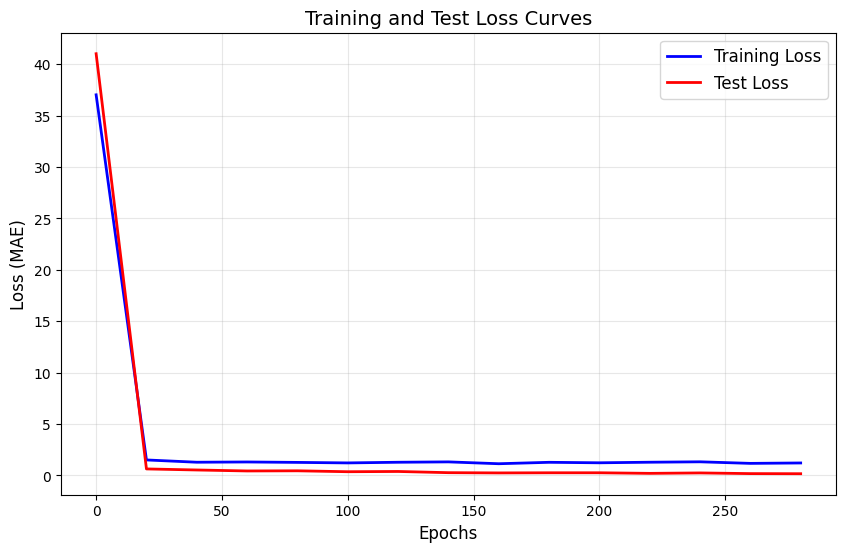

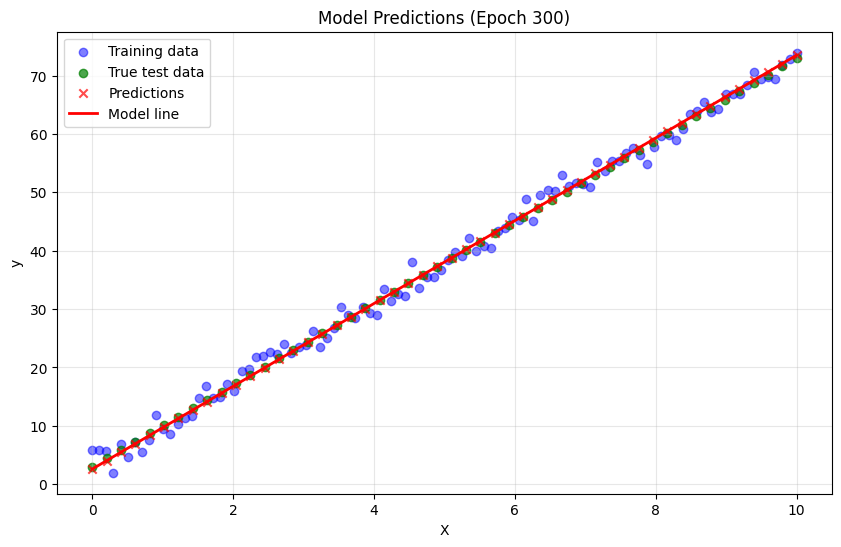


PARAMETER COMPARISON:
LEARNED PARAMETERS:
  weight: 7.093569
  bias: 2.578815

GROUND TRUTH PARAMETERS:
  weight: 7.0
  bias: 3.0

DIFFERENCE:
  weight error: 0.093569
  bias error: 0.421185

SAMPLE PREDICTIONS:
x = 1.0 -> Predicted: 9.672 | True: 10.000 | Error: 0.328
x = 2.0 -> Predicted: 16.766 | True: 17.000 | Error: 0.234
x = 5.0 -> Predicted: 38.047 | True: 38.000 | Error: 0.047
x = 8.0 -> Predicted: 59.327 | True: 59.000 | Error: 0.327


In [4]:
# Lecture 15

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# 1. CREATE SYNTHETIC DATA
# ============================================
# Ground truth: y = 7*x + 3
weight_true = 7.0
bias_true = 3.0

# Generate training data (with noise)
torch.manual_seed(42)
X_train = torch.linspace(0, 10, 100).reshape(-1, 1)
y_train = weight_true * X_train + bias_true + torch.randn(X_train.shape) * 1.5

# Generate test data (no noise - to see true performance)
X_test = torch.linspace(0, 10, 50).reshape(-1, 1)
y_test = weight_true * X_test + bias_true

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Ground truth: weight = {weight_true}, bias = {bias_true}")

# ============================================
# 2. CREATE DATALOADERS
# ============================================
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Number of training batches: {len(train_dataloader)}")
print(f"Number of test batches: {len(test_dataloader)}")

# ============================================
# 3. DEFINE THE MODEL
# ============================================
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True))

    def forward(self, x):
        return self.weight * x + self.bias

# Set random seed for reproducibility
torch.manual_seed(42)
model = LinearRegressionModel()

# Inspect initial parameters
print("\n" + "="*50)
print("INITIAL (RANDOM) PARAMETERS:")
print("="*50)
for name, param in model.state_dict().items():
    print(f"{name}: {param.item():.6f}")

# ============================================
# 4. MAKE PREDICTIONS BEFORE TRAINING
# ============================================
def plot_predictions(model, X_train, y_train, X_test, y_test, predictions=None, epoch=None):
    """Plot true data vs model predictions"""
    plt.figure(figsize=(10, 6))

    # Plot training data
    plt.scatter(X_train, y_train, c='blue', alpha=0.5, label='Training data')
    plt.scatter(X_test, y_test, c='green', alpha=0.7, label='True test data')

    # Plot predictions if provided
    if predictions is not None:
        plt.scatter(X_test, predictions, c='red', alpha=0.7, label='Predictions', marker='x')

    # Plot the line
    with torch.no_grad():
        x_line = torch.linspace(0, 10, 100).reshape(-1, 1)
        y_line = model(x_line)
        plt.plot(x_line, y_line, 'r-', label='Model line', linewidth=2)

    plt.xlabel('X')
    plt.ylabel('y')
    plt.title(f'Model Predictions (Epoch {epoch if epoch else "Initial"})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Make initial predictions
with torch.no_grad():
    initial_predictions = model(X_test)

plot_predictions(model, X_train, y_train, X_test, y_test, initial_predictions, epoch="Initial")

# ============================================
# 5. CONFIGURE LOSS FUNCTION AND OPTIMIZER
# ============================================
# Loss function: Mean Absolute Error (L1 Loss)
loss_fn = nn.L1Loss()

# Optimizer: Stochastic Gradient Descent
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

print("\n" + "="*50)
print("TRAINING CONFIGURATION:")
print("="*50)
print(f"Loss function: {loss_fn.__class__.__name__}")
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

# ============================================
# 6. TRAINING LOOP
# ============================================
# Tracking variables for loss curves
epoch_count = []
train_loss_values = []
test_loss_values = []

# Training hyperparameters
EPOCHS = 300
PRINT_INTERVAL = 20

print("\n" + "="*50)
print("TRAINING STARTING...")
print("="*50)

for epoch in range(EPOCHS):
    # ----- TRAINING PHASE -----
    model.train()  # Set model to training mode
    epoch_train_loss = 0.0
    num_train_batches = 0

    for batch_X, batch_y in train_dataloader:
        # Forward pass
        y_pred = model(batch_X)

        # Calculate loss
        loss = loss_fn(y_pred, batch_y)

        # Backward pass
        optimizer.zero_grad()  # Reset gradients
        loss.backward()        # Compute gradients
        optimizer.step()       # Update parameters

        # Accumulate loss
        epoch_train_loss += loss.item()
        num_train_batches += 1

    # Calculate average training loss for this epoch
    avg_train_loss = epoch_train_loss / num_train_batches

    # ----- TESTING PHASE -----
    model.eval()  # Set model to evaluation mode
    epoch_test_loss = 0.0
    num_test_batches = 0

    with torch.inference_mode():  # Disable gradient computation
        for batch_X, batch_y in test_dataloader:
            # Forward pass
            y_pred = model(batch_X)

            # Calculate loss
            loss = loss_fn(y_pred, batch_y)

            # Accumulate loss
            epoch_test_loss += loss.item()
            num_test_batches += 1

    # Calculate average test loss for this epoch
    avg_test_loss = epoch_test_loss / num_test_batches

    # Track losses for plotting
    if epoch % PRINT_INTERVAL == 0:
        epoch_count.append(epoch)
        train_loss_values.append(avg_train_loss)
        test_loss_values.append(avg_test_loss)

        print(f"Epoch {epoch:3d} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f}")

print("\n" + "="*50)
print("TRAINING COMPLETE!")
print("="*50)

# ============================================
# 7. PLOT LOSS CURVES
# ============================================
plt.figure(figsize=(10, 6))
plt.plot(epoch_count, train_loss_values, 'b-', label='Training Loss', linewidth=2)
plt.plot(epoch_count, test_loss_values, 'r-', label='Test Loss', linewidth=2)
plt.title('Training and Test Loss Curves', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (MAE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# 8. VISUALIZE FINAL PREDICTIONS
# ============================================
with torch.no_grad():
    final_predictions = model(X_test)

plot_predictions(model, X_train, y_train, X_test, y_test, final_predictions, epoch=EPOCHS)

# ============================================
# 9. COMPARE LEARNED VS GROUND TRUTH PARAMETERS
# ============================================
print("\n" + "="*50)
print("PARAMETER COMPARISON:")
print("="*50)

learned_params = model.state_dict()
print("LEARNED PARAMETERS:")
for param_name, param_value in learned_params.items():
    print(f"  {param_name}: {param_value.item():.6f}")

print("\nGROUND TRUTH PARAMETERS:")
print(f"  weight: {weight_true}")
print(f"  bias: {bias_true}")

print("\nDIFFERENCE:")
print(f"  weight error: {abs(learned_params['weight'].item() - weight_true):.6f}")
print(f"  bias error: {abs(learned_params['bias'].item() - bias_true):.6f}")

# ============================================
# 10. MAKE SAMPLE PREDICTIONS
# ============================================
print("\n" + "="*50)
print("SAMPLE PREDICTIONS:")
print("="*50)

sample_inputs = torch.tensor([[1.0], [2.0], [5.0], [8.0]])
with torch.no_grad():
    sample_outputs = model(sample_inputs)

for i, x in enumerate(sample_inputs):
    true_value = weight_true * x.item() + bias_true
    print(f"x = {x.item():.1f} -> Predicted: {sample_outputs[i].item():.3f} | True: {true_value:.3f} | Error: {abs(sample_outputs[i].item() - true_value):.3f}")

In [ ]:
# Lecture 16
from pathlib import Path

MODEL_PATH = Path("models")  # path object pointing to ./models
MODEL_PATH.mkdir(parents=True, exist_ok=True)

print(f"model directory created: {MODEL_PATH.absolute()}")

MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(MODEL_SAVE_PATH)

# SAVING the model weights
torch.save(obj=model_0.state_dict(), f=MODEL_SAVE_PATH)

if MODEL_SAVE_PATH.exists():
    file_size = MODEL_SAVE_PATH.stat().st_size
    print(file_size)
    print(len(model_0.state_dict()))
else:
    print("Model Save Failed")

# Loading the saved state dictionary
saved_state = torch.load(MODEL_SAVE_PATH)

for name, t in saved_state.items():
    if t.numel() == 1:
        print(name, t.item())
    else:
        print(f"{name}, shape = {tuple(t.shape)}, dtype = {t.dtype}")